In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [34]:
toyato_data = pd.read_csv(r"ToyotaCorolla - MLR.csv")
toyato_data

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


In [35]:
toyato_data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [36]:
toyato_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [37]:
toyato_data.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [38]:
toyato_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Price,1436.0,10730.824513,3626.964585,4350.0,8450.0,9900.0,11950.00,32500.0
Age_08_04,1436.0,55.947075,18.599988,1.0,44.0,61.0,70.00,80.0
KM,1436.0,68533.259749,37506.448872,1.0,43000.0,63389.5,87020.75,243000.0
HP,1436.0,101.502089,14.981080,69.0,90.0,110.0,110.00,192.0
Automatic,1436.0,0.055710,0.229441,0.0,0.0,0.0,0.00,1.0
cc,1436.0,1576.855850,424.386770,1300.0,1400.0,1600.0,1600.00,16000.0
Doors,1436.0,4.033426,0.952677,2.0,3.0,4.0,5.00,5.0
Cylinders,1436.0,4.000000,0.000000,4.0,4.0,4.0,4.00,4.0
Gears,1436.0,5.026462,0.188510,3.0,5.0,5.0,5.00,6.0
Weight,1436.0,1072.459610,52.641120,1000.0,1040.0,1070.0,1085.00,1615.0


In [39]:
numerical_data = toyato_data.select_dtypes(include=['number'])
correlation = numerical_data.corr()
correlation 

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
Price,1.000000,-0.876590,-0.569960,0.314990,0.033081,0.126389,0.185326,NaN,0.063104,0.581198
Age_08_04,-0.876590,1.000000,0.505672,-0.156622,0.031717,-0.098084,-0.148359,NaN,-0.005364,-0.470253
KM,-0.569960,0.505672,1.000000,-0.333538,-0.081854,0.102683,-0.036197,NaN,0.015023,-0.028598
HP,0.314990,-0.156622,-0.333538,1.000000,0.013144,0.035856,0.092424,NaN,0.209477,0.089614
Automatic,0.033081,0.031717,-0.081854,0.013144,1.000000,0.066740,-0.027654,NaN,-0.098555,0.057249
cc,0.126389,-0.098084,0.102683,0.035856,0.066740,1.000000,0.079903,NaN,0.014629,0.335637
Doors,0.185326,-0.148359,-0.036197,0.092424,-0.027654,0.079903,1.000000,NaN,-0.160141,0.302618
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,0.063104,-0.005364,0.015023,0.209477,-0.098555,0.014629,-0.160141,NaN,1.000000,0.020613
Weight,0.581198,-0.470253,-0.028598,0.089614,0.057249,0.335637,0.302618,NaN,0.020613,1.000000


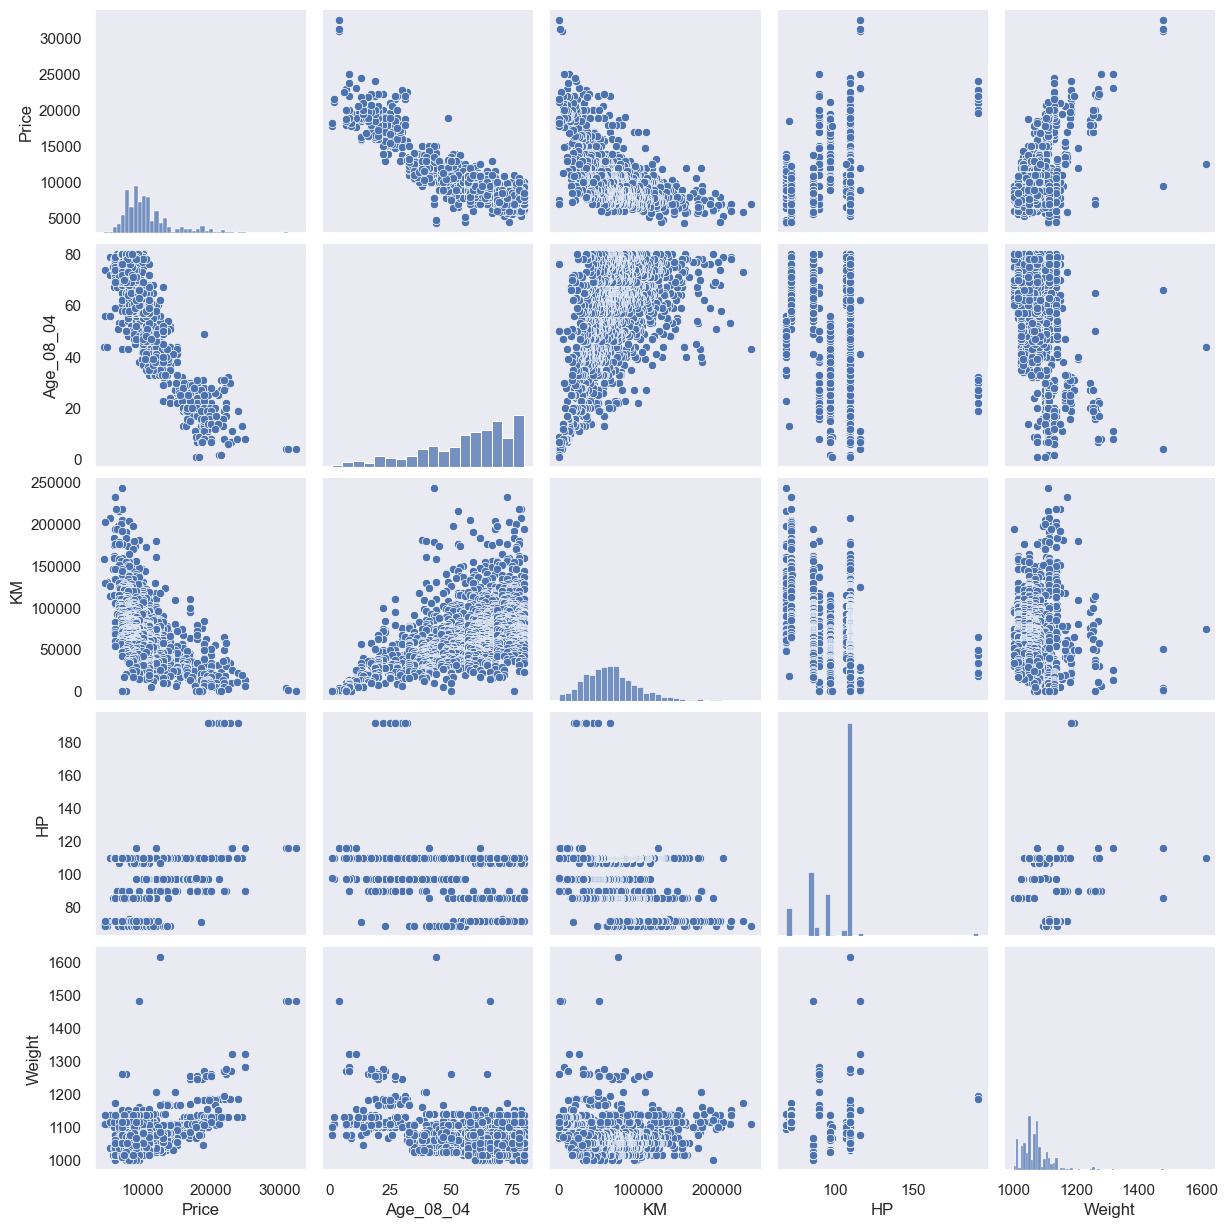

In [40]:
sns.set(style='dark')
pairplot_fig = sns.pairplot(toyato_data[['Price', 'Age_08_04', 'KM', 'HP', 'Weight']])

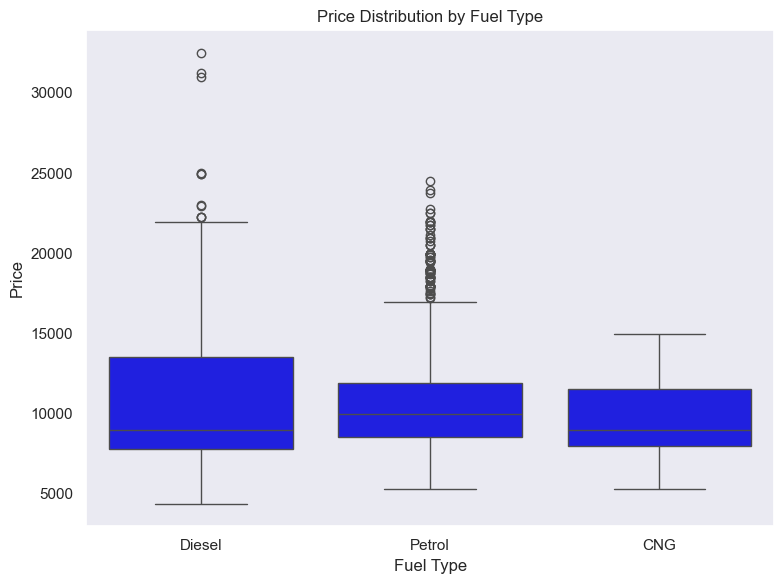

In [63]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Fuel_Type", y="Price", data= toyato_data, color="blue")

plt.title("Price Distribution by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


In [65]:
print(toyato_data[['Cylinders', 'cc', 'HP', 'Price']].corr())

           Cylinders        cc        HP     Price
Cylinders        NaN       NaN       NaN       NaN
cc               NaN  1.000000  0.035856  0.126389
HP               NaN  0.035856  1.000000  0.314990
Price            NaN  0.126389  0.314990  1.000000


In [68]:
x = toyato_data.drop(columns=['Price', 'Cylinders'])
y = toyato_data['Price']

In [69]:
df_num = ['Age_08_04', 'KM', 'HP', 'Automatic', 'cc',' Doors',' Gears', 'Weight']

In [70]:
categorical = ['Fuel_Type']
numerical = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
for cat in categorical:
    if cat in numerical:
        numerical.remove(cat)

In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [72]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('cat', OneHotEncoder(drop='first'), categorical)
    ]
)

In [73]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size =0.20,random_state =42)

In [74]:
print(x_train,y_train)

      Age_08_04      KM Fuel_Type   HP  Automatic    cc  Doors  Gears  Weight
899          62   59295    Petrol   86          0  1300      5      5    1035
881          68   61568    Petrol  110          0  1600      4      5    1035
310          40   38653    Petrol  110          0  1600      5      5    1080
1145         75  101855    Petrol  110          0  1600      5      5    1070
31           22   35199    Petrol   97          0  1400      3      5    1100
...         ...     ...       ...  ...        ...   ...    ...    ...     ...
1095         76  125778    Petrol  110          0  1600      3      5    1050
1130         73  107108    Petrol  110          0  1600      3      5    1050
1294         80   71740    Petrol  110          0  1600      5      5    1070
860          63   64690    Petrol   86          0  1300      3      5    1020
1126         80  110000    Petrol  110          0  1600      4      5    1035

[1148 rows x 9 columns] 899      9500
881      9795
310     129

In [75]:
print(x_test, y_test)

      Age_08_04      KM Fuel_Type   HP  Automatic    cc  Doors  Gears  Weight
594          50   22500    Petrol   97          0  1400      3      5    1025
754          68   80426    Petrol  110          0  1600      3      5    1055
630          59  130000    Diesel   72          0  2000      4      5    1135
1259         71   76000    Petrol  110          0  1600      5      5    1070
903          65   59000    Petrol  110          0  1600      5      5    1075
...         ...     ...       ...  ...        ...   ...    ...    ...     ...
174           8    9788    Petrol  110          0  1600      5      5    1130
1428         72   26000    Petrol   86          0  1300      3      5    1015
297          40   41339    Petrol  110          0  1600      5      5    1080
1435         76       1    Petrol  110          0  1600      5      5    1114
1009         59   36954    Petrol  110          0  1600      3      5    1050

[288 rows x 9 columns] 594     10800
754      9950
630      750

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline


In [77]:
model1 = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])
model1

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age_08_04', 'KM', 'HP',
                                                   'Automatic', 'cc', 'Doors',
                                                   'Gears', 'Weight']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Fuel_Type'])])),
                ('regressor', LinearRegression())])

In [78]:
model1.fit(x_train, y_train)
y_pred1 = model1.predict(x_test)

In [81]:
features2 = ['Age_08_04', 'KM', 'HP', 'Weight', 'Fuel_Type']
X2 = toyato_data[features2]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

In [83]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor2 = ColumnTransformer([
    ('num', StandardScaler(), ['Age_08_04', 'KM', 'HP', 'Weight']),
    ('cat', OneHotEncoder(drop='first'), ['Fuel_Type'])
])

In [84]:
model2 = Pipeline([
    ('preprocess', preprocessor2),
    ('regressor', LinearRegression())
])
model2

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age_08_04', 'KM', 'HP',
                                                   'Weight']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Fuel_Type'])])),
                ('regressor', LinearRegression())])

In [85]:
model2.fit(X2_train, y2_train)
y_pred2 = model2.predict(X2_test)

In [87]:
X3 = toyato_data[numerical]
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y, test_size=0.2, random_state=42)

In [88]:
model3 = Pipeline([
    ('scale', StandardScaler()),
    ('regressor', LinearRegression())
])
model3

Pipeline(steps=[('scale', StandardScaler()), ('regressor', LinearRegression())])

In [89]:
model3.fit (X3_train, y3_train)
y_pred3 = model3.predict(X3_test)

In [90]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [91]:

def evaluate(y_true, y_pred, label):
    print(f"\n{label}:")
    print("R^2:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

In [92]:
evaluate(y_test, y_pred1, "Model 1 - All Features")
evaluate(y2_test, y_pred2, "Model 2 - Selected Features")
evaluate(y3_test, y_pred3, "Model 3 - Numerical Only")


Model 1 - All Features:
R^2: 0.8348888040611081
MAE: 990.887273919397
MSE: 2203043.8231437043
RMSE: 1484.265415329652

Model 2 - Selected Features:
R^2: 0.8339087377576767
MAE: 1001.2769680084886
MSE: 2216120.6408832166
RMSE: 1488.664045674247

Model 3 - Numerical Only:
R^2: 0.8523452141908852
MAE: 997.0024057258142
MSE: 1970126.6288130332
RMSE: 1403.6119936838077


In [93]:
from sklearn.linear_model import LassoCV, RidgeCV

In [94]:
lasso = Pipeline([('preprocess', preprocessor),('regressor', LassoCV(cv=5))])
lasso.fit(x_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age_08_04', 'KM', 'HP',
                                                   'Automatic', 'cc', 'Doors',
                                                   'Gears', 'Weight']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Fuel_Type'])])),
                ('regressor', LassoCV(cv=5))])

In [95]:
y_lasso = lasso.predict(x_test)
evaluate(y_test, y_lasso, "Lasso Regression")


Lasso Regression:
R^2: 0.8521526948752264
MAE: 994.0603129183011
MSE: 1972695.373390202
RMSE: 1404.52674356532


In [96]:
ridge = Pipeline([('preprocess', preprocessor),('regressor', RidgeCV(cv=5))])
ridge.fit(x_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age_08_04', 'KM', 'HP',
                                                   'Automatic', 'cc', 'Doors',
                                                   'Gears', 'Weight']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Fuel_Type'])])),
                ('regressor', RidgeCV(cv=5))])

In [97]:
ridge.fit(x_train, y_train)
y_ridge = ridge.predict(x_test)
evaluate(y_test, y_ridge, "Ridge Regression")


Ridge Regression:
R^2: 0.8387827589612301
MAE: 990.1226859519676
MSE: 2151087.6051444784
RMSE: 1466.6586532470594


## Interview Questions

#### 1.What is Normalization & Standardization and how is it helpful?

**Normalization and Standardization are data preprocessing techniques used to scale numerical features so that machine learning models perform better.**
**Normalization:**
Normalization rescales data to a fixed range, usually **0 to 1**. It is useful when features have very different ranges and we want to ensure that no feature dominates others. It is commonly used in **distance-based algorithms** like KNN and K-Means.
**Standardization:**
Standardization transforms data so that it has **mean 0 and standard deviation 1**. It keeps the data centered and is useful when the data follows a normal distribution. It is widely used in algorithms like **Linear Regression, Logistic Regression, and SVM**.
**How it is helpful:**
* Brings all features to a common scale
* Improves model accuracy and convergence speed
* Prevents bias due to large-value features

#### 2.What techniques can be used to address multicollinearity in multiple linear regression?

Multicollinearity occurs when independent variables in a multiple linear regression are highly correlated with each other.
This can make coefficient estimates unstable and hard to interpret.

Techniques to address multicollinearity:
Remove one of the correlated variables
If two variables give similar information, we can drop one of them.
Check VIF (Variance Inflation Factor)
VIF helps detect multicollinearity. A high VIF value indicates a problem, and such variables can be removed.
Feature selection
Choose only the most important variables based on domain knowledge or statistical tests.
Principal Component Analysis (PCA)
Convert correlated variables into a smaller set of uncorrelated components.
Regularization techniques
Methods like Ridge Regression and Lasso Regression reduce the impact of multicollinearity by penalizing large coefficients.
